In [1]:
# ============================================================
# Social Media Sentiment & Engagement Tracker
# Step 1: Data Loading & Overview
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 20)

# Load both files
train = pd.read_csv('../data/raw/twitter_training.csv', 
                    header=None, 
                    names=['id', 'entity', 'sentiment', 'text'])

val = pd.read_csv('../data/raw/twitter_validation.csv', 
                  header=None, 
                  names=['id', 'entity', 'sentiment', 'text'])

# Combine into one dataset
df = pd.concat([train, val], ignore_index=True)

print("=== Dataset Overview ===")
print("Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nTop 10 Entities:")
print(df['entity'].value_counts().head(10))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSample rows:")
print(df.head(3))

=== Dataset Overview ===
Shape: (75682, 4)

Sentiment Distribution:
sentiment
Negative      22808
Positive      21109
Neutral       18603
Irrelevant    13162
Name: count, dtype: int64

Top 10 Entities:
entity
TomClancysRainbowSix         2435
LeagueOfLegends              2431
MaddenNFL                    2429
Microsoft                    2428
CallOfDuty                   2425
Verizon                      2414
ApexLegends                  2412
CallOfDutyBlackopsColdWar    2403
Facebook                     2403
WorldOfCraft                 2394
Name: count, dtype: int64

Missing Values:
id             0
entity         0
sentiment      0
text         686
dtype: int64

Sample rows:
     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getti

In [2]:
# ============================================================
# Step 2: Data Cleaning
# ============================================================

import re

# --- Drop missing text rows ---
df.dropna(subset=['text'], inplace=True)

# --- Drop 'Irrelevant' sentiment ---
df = df[df['sentiment'] != 'Irrelevant'].copy()

# --- Clean tweet text ---
def clean_text(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+', '', text)             # remove URLs
    text = re.sub(r'@\w+', '', text)                # remove mentions
    text = re.sub(r'#\w+', '', text)                # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)            # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

# --- Reset index ---
df.reset_index(drop=True, inplace=True)

print("=== After Cleaning ===")
print("Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nSample clean text:")
print(df[['text', 'clean_text']].head(3))

=== After Cleaning ===
Shape: (61949, 5)

Sentiment Distribution:
sentiment
Negative    22624
Positive    20932
Neutral     18393
Name: count, dtype: int64

Sample clean text:
                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   

                                          clean_text  
0  im getting on borderlands and i will murder yo...  
1  i am coming to the borders and i will kill you...  
2  im getting on borderlands and i will kill you all  


In [5]:
# ============================================================
# Step 3: Sentiment Scoring with VADER & TextBlob
# ============================================================

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# --- Initialize VADER ---
analyzer = SentimentIntensityAnalyzer()

# --- Apply VADER ---
print("Running VADER... (may take a minute)")
df['vader_score'] = df['clean_text'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

# VADER label: compound > 0.05 = Positive, < -0.05 = Negative, else Neutral
def vader_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_score'].apply(vader_label)

# --- Apply TextBlob ---
print("Running TextBlob...")
df['textblob_score'] = df['clean_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

def textblob_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_sentiment'] = df['textblob_score'].apply(textblob_label)

print("\n=== VADER Sentiment Distribution ===")
print(df['vader_sentiment'].value_counts())

print("\n=== TextBlob Sentiment Distribution ===")
print(df['textblob_sentiment'].value_counts())

print("\n=== Sample Scores ===")
print(df[['clean_text', 'sentiment', 'vader_sentiment', 
           'vader_score', 'textblob_score']].head(5))

Running VADER... (may take a minute)
Running TextBlob...

=== VADER Sentiment Distribution ===
vader_sentiment
Positive    27765
Negative    23050
Neutral     11134
Name: count, dtype: int64

=== TextBlob Sentiment Distribution ===
textblob_sentiment
Positive    28099
Negative    18237
Neutral     15613
Name: count, dtype: int64

=== Sample Scores ===
                                          clean_text sentiment  \
0  im getting on borderlands and i will murder yo...  Positive   
1  i am coming to the borders and i will kill you...  Positive   
2  im getting on borderlands and i will kill you all  Positive   
3  im coming on borderlands and i will murder you...  Positive   
4  im getting on borderlands and i will murder yo...  Positive   

  vader_sentiment  vader_score  textblob_score  
0        Negative      -0.6908             0.0  
1        Negative      -0.6908             0.0  
2        Negative      -0.6908             0.0  
3        Negative      -0.6908             0.0  
4   

=== Model Accuracy vs Original Labels ===
VADER Accuracy:    49.77%
TextBlob Accuracy: 48.26%


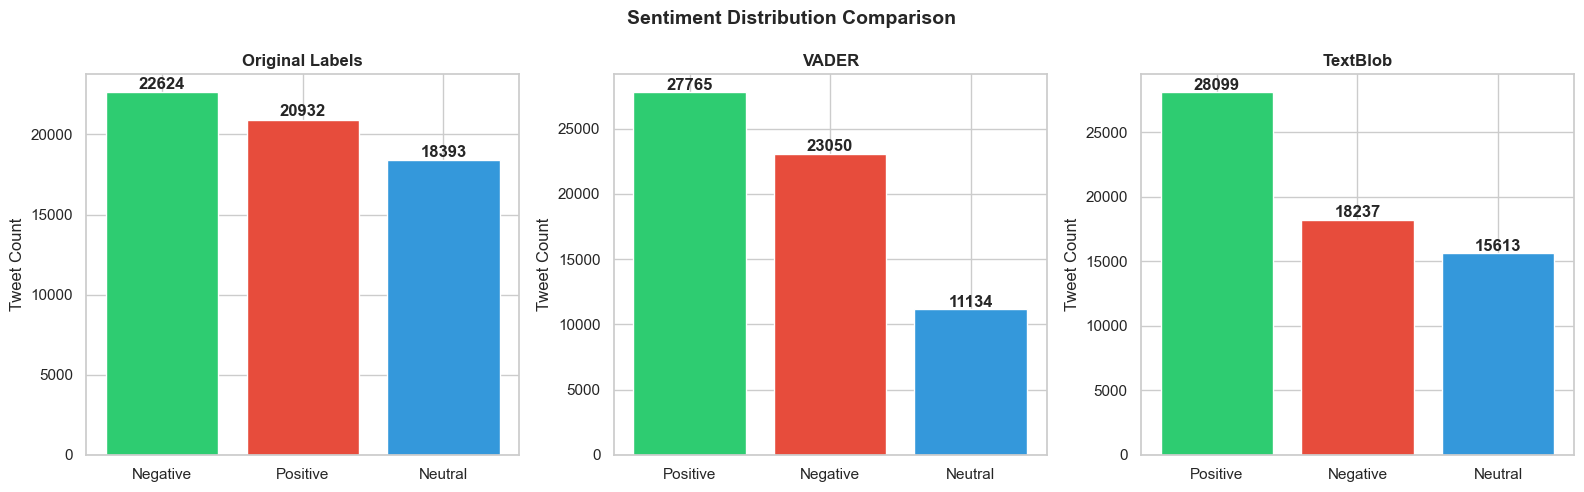

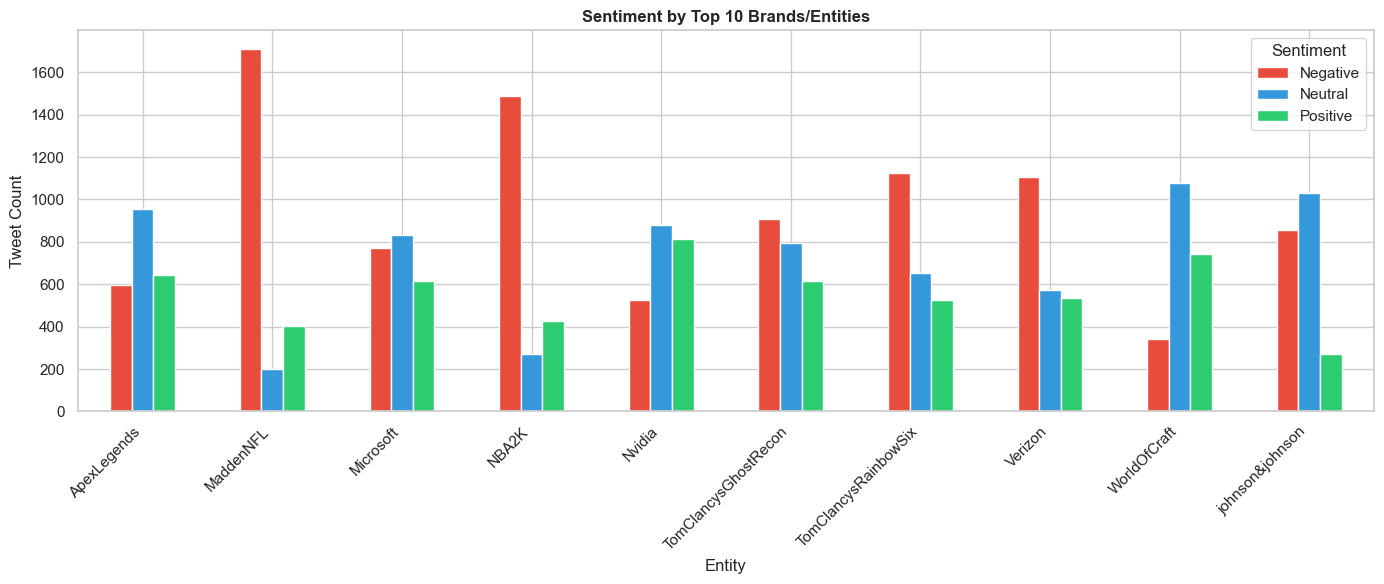

✅ Charts saved!


In [6]:
# ============================================================
# Step 4: Accuracy & Visualizations
# ============================================================

from sklearn.metrics import accuracy_score

# --- Accuracy vs original labels ---
vader_acc = accuracy_score(df['sentiment'], df['vader_sentiment'])
textblob_acc = accuracy_score(df['sentiment'], df['textblob_sentiment'])

print("=== Model Accuracy vs Original Labels ===")
print(f"VADER Accuracy:    {vader_acc*100:.2f}%")
print(f"TextBlob Accuracy: {textblob_acc*100:.2f}%")

# --- Plot 1: Sentiment Distribution Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Distribution Comparison', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes,
    ['sentiment', 'vader_sentiment', 'textblob_sentiment'],
    ['Original Labels', 'VADER', 'TextBlob']):
    counts = df[col].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    ax.bar(counts.index, counts.values, color=colors[:len(counts)])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Tweet Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/sentiment_distribution_comparison.png', dpi=150)
plt.show()

# --- Plot 2: Sentiment by Top 10 Entities ---
top_entities = df['entity'].value_counts().head(10).index
entity_df = df[df['entity'].isin(top_entities)]
entity_sentiment = entity_df.groupby(['entity', 'sentiment']).size().unstack(fill_value=0)

entity_sentiment.plot(kind='bar', figsize=(14, 6), 
                      color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Sentiment by Top 10 Brands/Entities', fontweight='bold')
plt.xlabel('Entity')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('../visuals/sentiment_by_entity.png', dpi=150)
plt.show()

print("✅ Charts saved!")

In [7]:
# ============================================================
# Step 5: VADER Score Distribution & Engagement Analysis
# ============================================================

# --- Plot 1: VADER Score Distribution by Original Sentiment ---
plt.figure(figsize=(12, 5))
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#3498db'}

for sentiment, color in colors.items():
    subset = df[df['sentiment'] == sentiment]['vader_score']
    plt.hist(subset, bins=50, alpha=0.5, label=sentiment, color=color)

plt.title('VADER Score Distribution by Sentiment Label', fontweight='bold')
plt.xlabel('VADER Compound Score')
plt.ylabel('Tweet Count')
plt.axvline(x=0.05, color='black', linestyle='--', linewidth=1, label='Positive threshold')
plt.axvline(x=-0.05, color='gray', linestyle='--', linewidth=1, label='Negative threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/vader_score_distribution.png', dpi=150)
plt.show()

# --- Plot 2: Average VADER Score by Entity (Top 15) ---
entity_vader = df.groupby('entity')['vader_score'].mean().sort_values()
top_bottom = pd.concat([entity_vader.head(8), entity_vader.tail(8)])

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_bottom.values]
plt.barh(top_bottom.index, top_bottom.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Most Positive vs Most Negative Brands (Avg VADER Score)', 
          fontweight='bold')
plt.xlabel('Average VADER Compound Score')
plt.tight_layout()
plt.savefig('../visuals/brand_vader_scores.png', dpi=150)
plt.show()

# --- Key Stats ---
print("=== Key Engagement Stats ===")
print(f"Total tweets analysed: {len(df):,}")
print(f"\nSentiment breakdown:")
print(df['sentiment'].value_counts())
print(f"\nMost negative brand:

SyntaxError: unterminated string literal (detected at line 43) (3155924758.py, line 43)